In [26]:
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
csv = r"C://Users//azeve//OneDrive//Área de Trabalho//projetos//tech_challenge//data//Obesity (1).csv"
df = pd.read_csv(csv)

In [28]:
df["Obesity"].value_counts()

Obesity
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64

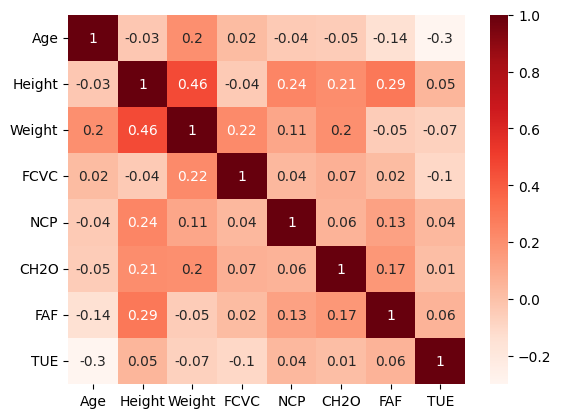

In [29]:
correlacao = df.corr(numeric_only=True).round(2)
plt.Figure(figsize=(100,100))
sns.heatmap(correlacao, cmap="Reds", annot=True)
plt.show()

In [30]:
x = df.drop(columns=["Obesity"])
y = df["Obesity"]


categoricas = x.select_dtypes(include=["object"]).columns.tolist()
numericas = [c for c in x.columns if c not in categoricas]

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categoricas),
        ("num", StandardScaler(), numericas),
    ],
    remainder="drop"
)

C:\Users\azeve\AppData\Local\Temp\ipykernel_12728\1138476641.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categoricas = x.select_dtypes(include=["object"]).columns.tolist()


In [33]:
x_treino, x_test, y_treino, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)
model = Pipeline(steps=[
    ("prep", preprocess),
    ("logreg", LogisticRegression(
        solver="lbfgs",
        C=2.0,
        max_iter=5000
    ))
])

model.fit(x_treino, y_treino)


y_pred = model.predict(x_test)
acc = accuracy_score(y_test, y_pred)
f1m = f1_score(y_test, y_pred, average="macro")

print(f"Acurácia (teste): {acc:.4f}")
print(f"F1 (teste): {f1m:.4f}\n")
print("Relatório de classificação:")
print(classification_report(y_test, y_pred))



Acurácia (teste): 0.8983
F1 (teste): 0.8959

Relatório de classificação:
                     precision    recall  f1-score   support

Insufficient_Weight       0.95      1.00      0.97        54
      Normal_Weight       0.82      0.78      0.80        58
     Obesity_Type_I       0.93      0.93      0.93        70
    Obesity_Type_II       0.94      0.97      0.95        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.76      0.81      0.78        58
Overweight_Level_II       0.89      0.81      0.85        58

           accuracy                           0.90       423
          macro avg       0.90      0.90      0.90       423
       weighted avg       0.90      0.90      0.90       423



In [34]:
y.value_counts(normalize=True)

Obesity
Obesity_Type_I         0.166272
Obesity_Type_III       0.153482
Obesity_Type_II        0.140692
Overweight_Level_I     0.137376
Overweight_Level_II    0.137376
Normal_Weight          0.135955
Insufficient_Weight    0.128849
Name: proportion, dtype: float64

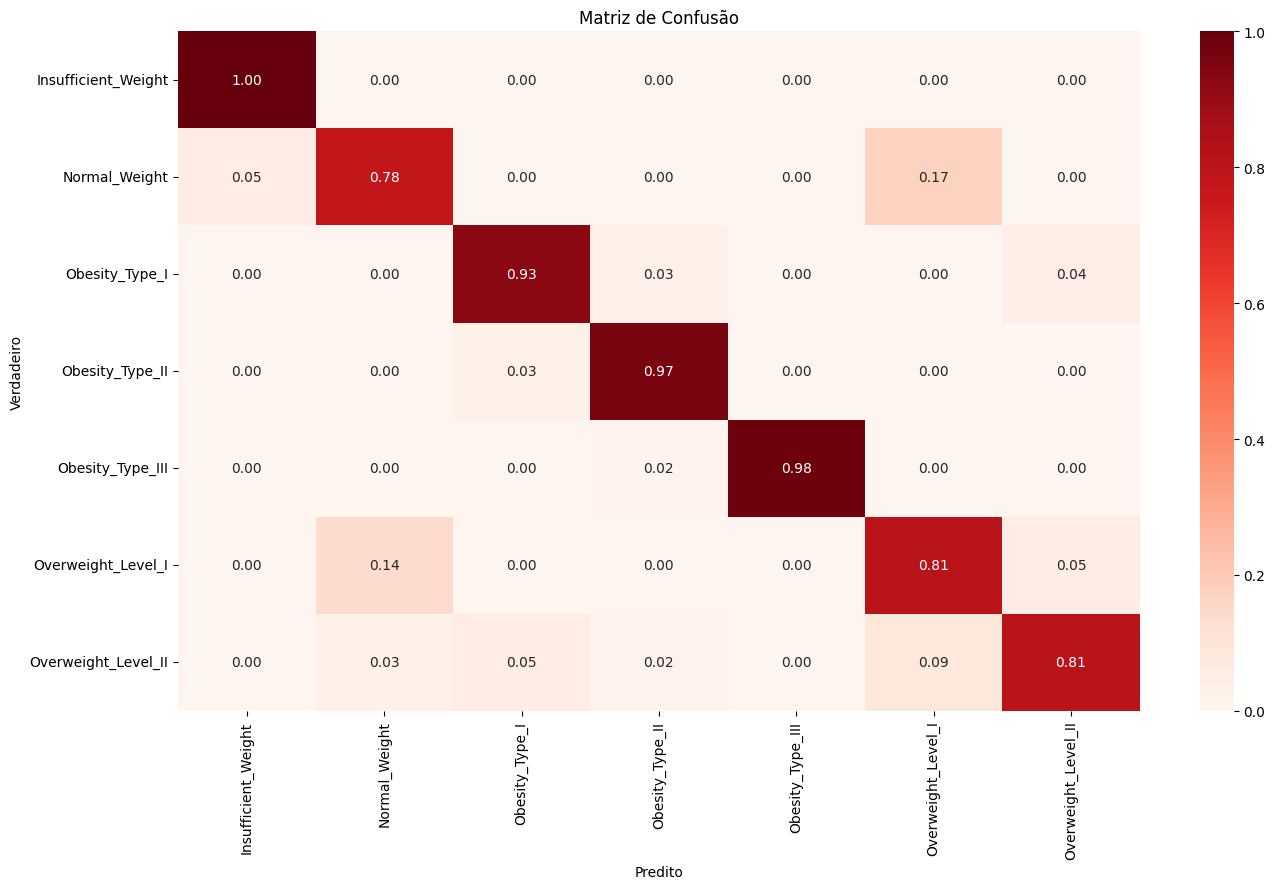

In [35]:
labels = np.sort(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels, normalize="true")

plt.figure(figsize=(14, 9))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Reds",
            xticklabels=labels, yticklabels=labels)
plt.title("Matriz de Confusão")
plt.xlabel("Predito")
plt.ylabel("Verdadeiro")
plt.tight_layout()
plt.show()


from sklearn.metrics import precision_recall_fscore_support
_, _, f1_per_class, _ = precision_recall_fscore_support(
    y_test, y_pred, labels=labels, zero_division=0
)


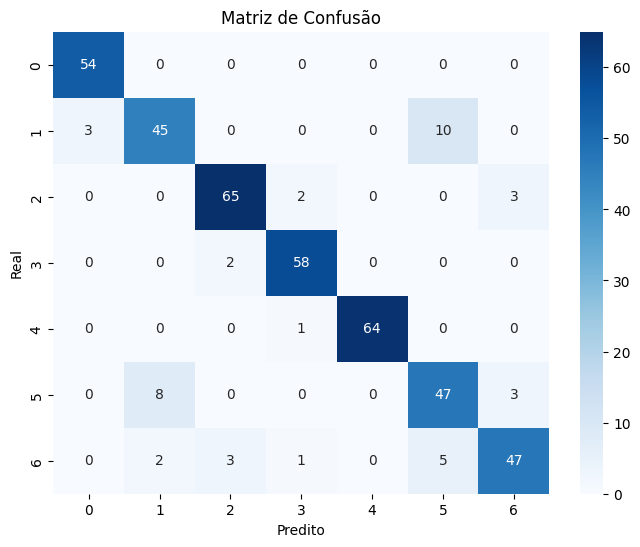

In [36]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de Confusão")
plt.ylabel("Real")
plt.xlabel("Predito")
plt.show()

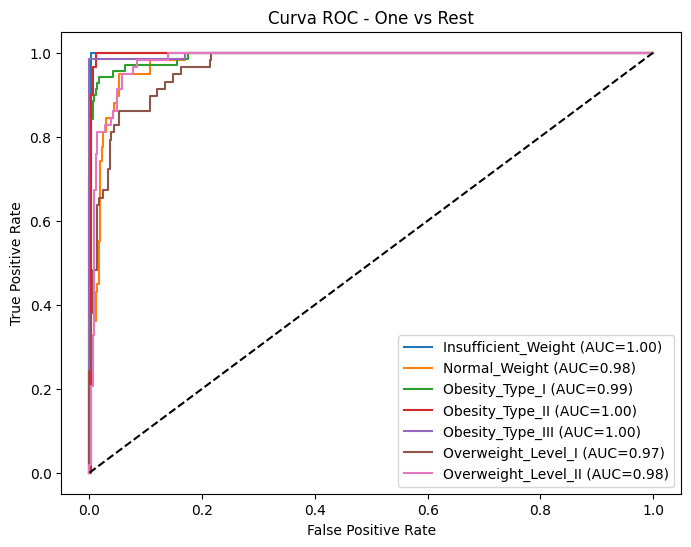

In [37]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)

y_proba = model.predict_proba(x_test)

plt.figure(figsize=(8,6))

for i, classe in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{classe} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.title("Curva ROC - One vs Rest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()